In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [1]:
import pandas as pd
import wandb
from tqdm import tqdm

api = wandb.Api(timeout=50)

runs = api.runs("lab_frohlich/DeepMechanisticModels.v38.dream_cytof")

all_rows = []
for run in tqdm(runs):
    context = run.config.get("context")
    samples = run.config.get("samples")
    n_hidden = run.config.get("n_hidden")
    depth = run.config.get("depth")
    features = run.config.get("features")
    features_selection = run.config.get("features_selection")
    job = run.config.get("job")
    l1reg_inflater_output = run.config.get("l1reg_inflater_output")
    inflater_output_reg_epoch = run.config.get("inflater_output_reg_epoch")
    l2reg_inflater_output = run.config.get("l2reg_inflater_output")
    sparse_threshold_perc = run.config.get("sparse_threshold_perc")

    try:
        history = run.scan_history(
            keys=["rmse_train", "rmse_val", "_step"],
        )
    except Exception as e:
        print(f"Skipping run {run.id} due to error: {e}")
        continue

    for row in history:
        if row.get("rmse_train") is not None and row.get("rmse_val") is not None:
            all_rows.append({
                # Config
                "context": context,
                "samples": samples,
                "n_hidden": n_hidden,
                "depth": depth,
                "features": features,
                "features_selection": features_selection,
                "job": job,
                "l1reg_inflater_output": l1reg_inflater_output,
                "inflater_output_reg_epoch": inflater_output_reg_epoch,
                "l2reg_inflater_output": l2reg_inflater_output,
                "sparse_threshold_perc": sparse_threshold_perc,
                # Epoch
                "step": row["_step"],
                # RMSEs
                "rmse_train": row["rmse_train"],
                "rmse_val": row["rmse_val"],
            })

results_df = pd.DataFrame(all_rows)
results_df.to_csv("results_linear_scans_v38.csv", index=False)

100%|██████████| 775/775 [07:28<00:00,  1.73it/s]


,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
0,transcriptomics,1of5,4,0,HVGRFE_20_permute,None,3,100.0,100,0,gmm,1,0.518166,0.830702
1,transcriptomics,1of5,4,0,HVGRFE_20_permute,None,3,100.0,100,0,gmm,13,0.443395,0.769414
2,transcriptomics,1of5,4,0,HVGRFE_20_permute,None,3,100.0,100,0,gmm,26,0.420465,0.653435
3,transcriptomics,1of5,4,0,HVGRFE_20_permute,None,3,100.0,100,0,gmm,36,0.412914,0.657506
4,transcriptomics,1of5,4,0,HVGRFE_20_permute,None,3,100.0,100,0,gmm,50,0.406901,0.701520


In [23]:
df_37 = pd.read_csv("results_feature_selection_v37.csv")
df_37_tx = df_37[(df_37["context"] == 'transcriptomics') & (df_37["features"] == 'HVGRFE_20_permute') & (df.step == df.step.max())]
df_37_tx

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
119,transcriptomics,0of5,2,0,HVGRFE_20_permute,NaN,1,100,100,0,gmm,499,0.407610,0.481171
203,transcriptomics,3of5,2,0,HVGRFE_20_permute,NaN,3,100,100,0,gmm,499,0.415039,0.557543
479,transcriptomics,0of5,2,0,HVGRFE_20_permute,NaN,4,100,100,0,gmm,499,0.411278,0.533117
587,transcriptomics,2of5,2,0,HVGRFE_20_permute,NaN,0,100,100,0,gmm,499,0.418916,0.393296
599,transcriptomics,4of5,2,0,HVGRFE_20_permute,NaN,4,100,100,0,gmm,499,0.404065,0.720441
767,transcriptomics,2of5,2,0,HVGRFE_20_permute,NaN,4,100,100,0,gmm,499,0.395283,0.435210
827,transcriptomics,1of5,2,0,HVGRFE_20_permute,NaN,3,100,100,0,gmm,499,0.408475,0.737667
1595,transcriptomics,4of5,2,0,HVGRFE_20_permute,NaN,2,100,100,0,gmm,499,0.408109,0.658849
1655,transcriptomics,1of5,2,0,HVGRFE_20_permute,NaN,2,100,100,0,gmm,499,0.407106,0.649407
1667,transcriptomics,3of5,2,0,HVGRFE_20_permute,NaN,4,100,100,0,gmm,499,0.411074,0.416721


In [24]:
df_37_px = df_37[(df_37["context"] == 'proteomics') & (df_37["features"] == 'HVGRFE_15_permute') & (df.step == df.step.max())]
df_37_px
# note: sample 0of5 missing, not sure which wandb project it is in

,context,samples,n_hidden,depth,features,features_selection,job,l1reg_inflater_output,inflater_output_reg_epoch,l2reg_inflater_output,sparse_threshold_perc,step,rmse_train,rmse_val
347,proteomics,2of5,2,0,HVGRFE_15_permute,NaN,1,100,100,0,gmm,499,0.399167,0.329903
431,proteomics,2of5,2,0,HVGRFE_15_permute,NaN,0,100,100,0,gmm,499,0.387443,0.388761
491,proteomics,1of5,2,0,HVGRFE_15_permute,NaN,1,100,100,0,gmm,499,0.397887,0.890134
647,proteomics,4of5,2,0,HVGRFE_15_permute,NaN,3,100,100,0,gmm,499,0.395230,0.595927
1043,proteomics,1of5,2,0,HVGRFE_15_permute,NaN,3,100,100,0,gmm,499,0.410128,0.441037
1367,proteomics,2of5,2,0,HVGRFE_15_permute,NaN,3,100,100,0,gmm,499,0.394993,0.452902
1403,proteomics,2of5,2,0,HVGRFE_15_permute,NaN,4,100,100,0,gmm,499,0.405102,0.619183
1415,proteomics,1of5,2,0,HVGRFE_15_permute,NaN,2,100,100,0,gmm,499,0.415258,0.366099
1895,proteomics,3of5,2,0,HVGRFE_15_permute,NaN,1,100,100,0,gmm,499,0.397054,0.445679
1919,proteomics,3of5,2,0,HVGRFE_15_permute,NaN,3,100,100,0,gmm,499,0.397105,0.522576


In [25]:
df = pd.read_csv("results_linear_scans_v38.csv")
df = pd.concat([df, df_37_px, df_37_tx])
df[df.step == df.step.max()].groupby(['n_hidden', 'depth', 'inflater_output_reg_epoch', 'context']).agg('count')

samples  features  \
n_hidden depth inflater_output_reg_epoch context                              
2        0     50                        cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
               100                       cytof_init            25        25   
                                         proteomics            20        20   
                                         transcriptomics       25        25   
               200                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
               300                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
               400                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
               500                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
         1     100                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
         2     100                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
3        0     100                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
4        0     100                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   
6        0     100                       cytof_init            25        25   
                                         proteomics            25        25   
                                         transcriptomics       25        25   

                                                          features_selection  \
n_hidden depth inflater_output_reg_epoch context                               
2        0     50                        cytof_init                        0   
                                         proteomics                        0   
                                         transcriptomics                   0   
               100                       cytof_init                        0   
                                         proteomics                        0   
                                         transcriptomics                   0   
               200                       cytof_init                        0   
                                         proteomics                        0   
                                         transcriptomics                   0   
               300                       cytof_init                        0   
                                         proteomics                        0   
                                         transcriptomics                   0   
               400                       cytof_init                        0   
                                         proteomics                        0   
            

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

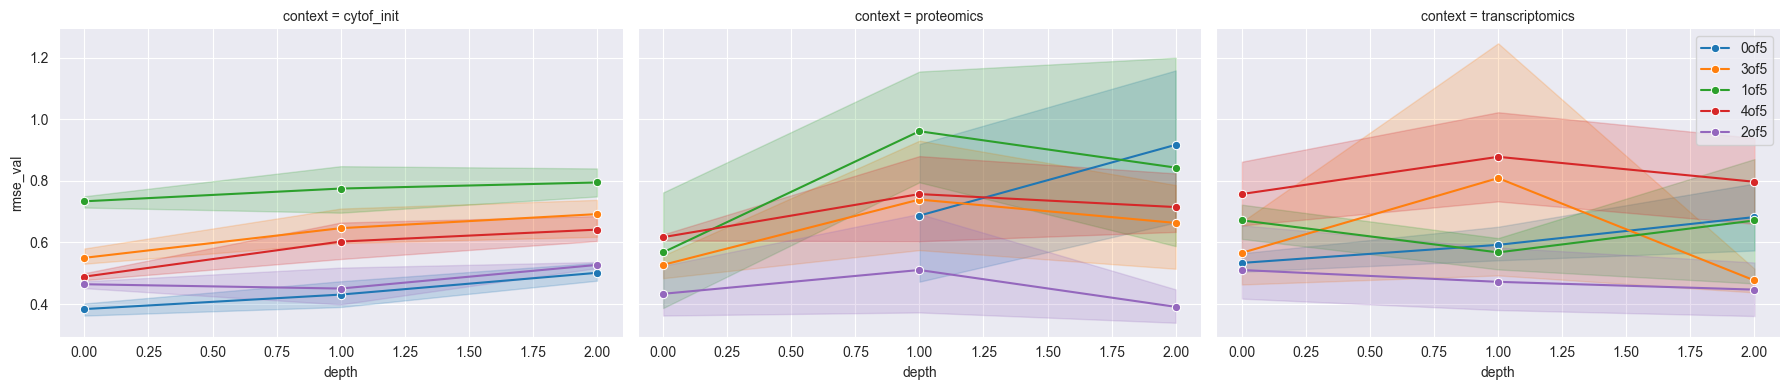

In [33]:
depth_scan = df[(df.inflater_output_reg_epoch == 100) & (df.step == df.step.max()) & (df.n_hidden == 2)]

g = sns.FacetGrid(
    depth_scan ,
    col="context",
    col_order=sorted(depth_scan ["context"].unique()),
    hue="samples",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

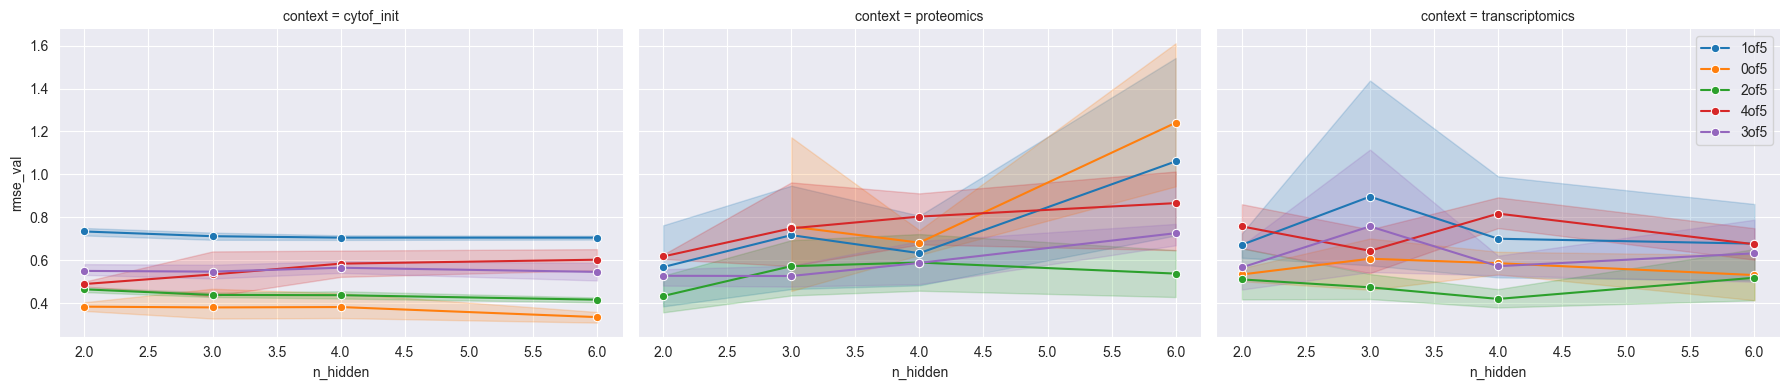

In [32]:
width_scan = df[(df.inflater_output_reg_epoch == 100) & (df.step == df.step.max()) & (df.depth == 0)]

g = sns.FacetGrid(
    width_scan,
    col="context",
    col_order=sorted(width_scan["context"].unique()),
    hue="samples",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()

/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/frohlif/Documents/projects/DeepMechanisticModels/venv/

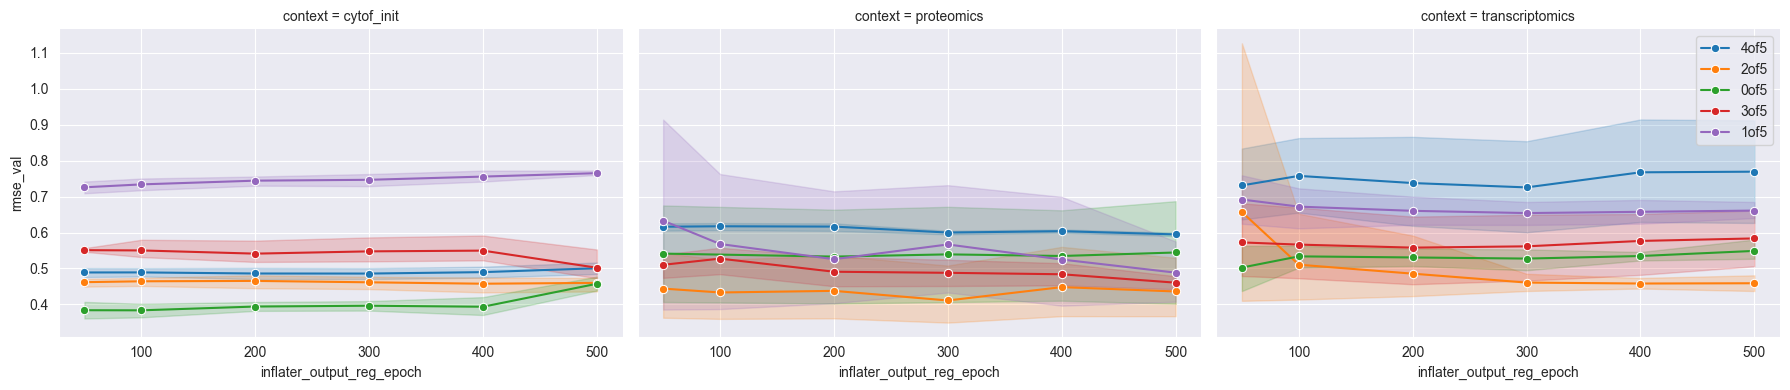

In [31]:
epoch_scan = df[(df.step == df.step.max()) & (df.depth == 0) & (df.n_hidden == 2)]

g = sns.FacetGrid(
    epoch_scan,
    col="context",
    col_order=sorted(epoch_scan["context"].unique()),
    hue="samples",
    height=4,
    aspect=1.5
)
g.map_dataframe(
    sns.lineplot,
    x="inflater_output_reg_epoch",
    y="rmse_val",
    marker="o",
    dashes=False
)
plt.legend()